# Import Packages

In [19]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix





# Load Dataset

In [20]:
data = pd.read_csv('BsalBdDataFull.csv')

data.columns


Index(['SwabID', 'CollectionDate', 'TaxaID', 'ScientificName', 'SiteName',
       'State', 'County', 'Latitude', 'Longitude', 'Elevation_m', 'Sex', 'Age',
       'BodyLength', 'CaptureEnvironment', 'Bsal.Result', 'Case', 'Acc',
       'Bdct', 'Bd.Result', 'copyNum', 'Gesp', 'order', 'siteID', 'siteVID',
       'reg', 'KGzone', 'KG5', 'KG3', 'm1max', 'm7max', 'm10max', 'm20max',
       'm30max', 'm40max', 'm50max', 'm60max', 'm70max', 'm80max', 'm90max',
       'm100max', 'm110max', 'm120max', 'm1min', 'm7min', 'm10min', 'm20min',
       'm30min', 'm40min', 'm50min', 'm60min', 'm70min', 'm80min', 'm90min',
       'm100min', 'm110min', 'm120min', 't1precip', 't7precip', 't10precip',
       't20precip', 't30precip', 't40precip', 't50precip', 't60precip',
       't70precip', 't80precip', 't90precip', 't100precip', 't110precip',
       't120precip'],
      dtype='object')

# Understanding the Dataset

I wanted to have a list of all the column names, plus definitions as needed, as some of the column names aren't clear initially. The data is explained in the BD_Bsal_Data_Release.xml file.


SwabID - Barcode or submitter-assigned identification number

CollectionDate - Date of field swab collection

TaxaID - Numeric code for species corresponding to the Integrated Taxonomic Information System (ITIS) found at https://www.itis.gov/

ScientificName - Species Name

SiteName - Submitter-assigned site name where swabs were collected

State 

County

Latitude

Longitude

Elevation_m

Sex - Can be Male, Female, or Unknown

Age - Written as NA if age was not ascertained. Otherwise Adult, Juvenile, or Larval.

BodyLength - The body length of the swabbed individual. For amphibians, this is the straight-line distance from the tip of the snout to the vent. It does not include the tail length. An NA is denoted for those records where body length was not measured.

CaptureEnvironment - The habitat in which the swabbed animal was captured. Either aquatic or terrestrial

Bsal.Result - binary result for Bsal PCR, positive = detected, negative = not detected. Bsal is salamander chytrid fungus, which was not detected. This is separate from the result for amphibian chytrid fungus, which was detected. 

Case - Internal lab identifier for group of samples received in the same shipment

Acc - Internal lab identifier for individual sample within a Case

Bdct - Cycle threshold value from PCR reaction (max=40). Lower values indicate more target DNA in sample.  Measured at the PCR cycle where a signal was detected at 5% of max fluorescence and subsequent signal followed a true amplification curve. NA = no signal detected; No Amp = signal detected, but due to signal noise and not amplification of the target; equivocal = signal detected during last cycle with likely amplification, but reaction cycles stopped before true amplification could be determined.

Bd.Result - Interpretation of quantitative PCR results. Positive = true amplification signal detected; Negative = no fluorescent signal detected; No Amp = signal detected, but due to signal noise and not amplification of the target. Manually confirmed during lab QA/QC; equivocal = signal detected during last cycle with likely amplification, but reaction cycles stopped before true amplification could be determined.

copyNum - Calculated estimate of the number of target DNA copies per sample

Gesp - Genus and species used to estimate phylogenetic distance

order - taxonomic order

siteID - numeric index that groups samples within 0.2km to a site

siteVID - numeric index for site visits that occurred greater than 5 days apart at each site

reg - NOAA climate region where the site was sampled

KGzone - 3rd level Köppen-Geiger climate zone where the sample was collected

KG5 - 2nd level Köppen-Geiger climate zone where the sample was collected

KG3 - 1st level Köppen-Geiger climate zone where the sample was collected

m1max - maximum daily temperature estimated at the day of sampling

m7max, m10max, m20max, m30max, m40max, m50max, m60max, m70max, m80max, m90max, m100max, m110max, m120max - average maximum daily temperature estimated for the 7, 10, 20, etc days preceding sampling<

m1min - minimum daily temperature estimated at the day of sampling

m7min, m10min, m20min, m30min, m40min, m50min, m60min, m70min, m80min, m90min, m100min, m110min, m120min - average minimum daily temperature estimated for the 7, 10, 20, etc days preceding sampling

t1precip - total precipitation estimated on the day of sampling

t7precip, t10precip, t20precip, t30precip, t40precip, t50precip, t60precip, t70precip, t80precip, t90precip, t100precip, t110precip, t120precip - total precipitation estimated over the 7, 10, 20, etc days preceding sampling

# Cleaning the Dataset

Columns that should be removed:

SwabID (it is just a sample identifier), TaxaID (It's like scientific name but less detail), SiteName (too specific), County (too specific), Bsal.Result (all of the results were negative), Case (sample identifier), Acc (sample identifier), Bdct (used to determine the value in the Bd column), copyNum (used to determine the value in the Bd column), Gesp (it's the same as scientific name), siteID (we already have values for the site), siteVID (we already have values for the site), KG5 (similar to KGzone), KG3 (similar to KGzone).

Columns that should be changed:

I should separate out Gesp to separate Genus and Species Columns and remove Gesp. For CollectionDate, I will separate out the month into one column, and the year into another column and remove CollectionDate. 

In [21]:
#Drop unnecessary columns
data = data.drop(columns = ["SwabID","TaxaID", "SiteName", "County", "Bsal.Result", "Case", "Acc", "Bdct", "copyNum", "Gesp", "siteID", "siteVID", "KG5", "KG3"])

#separate the ScientificName column into Genus and Species Columns. Remove ScientificName. 
data[['Genus', 'Species']] = data['ScientificName'].str.split(' ', n=1, expand=True)
data = data.drop(columns = ['ScientificName'])

#separate the CollectionDate column into Month and Year Columns. Remove CollectionDate
data[['Month', 'Day', 'Year']] = data['CollectionDate'].str.split('/', n = 2, expand = True)
data = data.drop(columns = ['CollectionDate', 'Day'])

I also want to look at columns with unique values or columns with missing values, to see if any more columns or rows should be removed. From this, I can tell that I should drop the Genus column because there's only one Genus. I also want to remove any rows without an elevation, because I think that could be a useful piece of information to study. I should also remove rows without a value in Bd.Result.

In [22]:
pd.set_option('display.max_rows', None) #tell python to display all the rows

print("Unique values:")
print(data.nunique().sort_values())

print("Missing values:")
print(data.isna().sum().sort_values(ascending=False))

pd.reset_option('display.max_rows') #tell python to stop displaying all the rows

Unique values:
CaptureEnvironment      2
Bd.Result               2
order                   2
Sex                     3
Age                     3
Year                    4
reg                     9
KGzone                 10
Month                  11
Genus                  19
State                  35
Species                54
BodyLength            163
t1precip              262
Elevation_m           346
t7precip              559
t10precip             588
Longitude             603
Latitude              604
t20precip             634
t30precip             639
t40precip             649
m1max                 652
t50precip             652
m1min                 654
t60precip             655
t100precip            657
t70precip             658
t80precip             658
t90precip             659
t120precip            659
t110precip            660
m7max                 662
m10min                662
m20min                663
m7min                 663
m110max               663
m120max               6

In [23]:
#Remove any rows with NA
data = data.dropna(subset=['Elevation_m'])
data = data.dropna(subset=['Bd.Result'])
data = data.dropna(subset=['BodyLength'])
data = data.dropna(subset=['Sex'])
data = data.dropna(subset=['Age'])
data = data.dropna(subset=['Species'])

#There is one huge outlier in my BodyLength Category. I'd like to remove that
data = data[data['BodyLength'] <= 300]


# Data Preparation

I need to make sure all of my data types are correct

In [24]:
print(data['Species'].unique())

['viridescens' 'chiricahuensis' 'mavortium' 'californiense' 'sp.' 'torosa'
 'granulosa' 'sierrae' 'nigriventris' 'muscosa' 'ensatus' 'eschscholtzii'
 'tenebrosus' 'boreas' 'catesbeianus' 'perstriatus' 'talpoideum'
 'tigrinum' 'cingulatum' 'cirrigera' 'opacum' 'ruber' 'glutinosus'
 'cinereus' 'intermedia' 'maculatum' 'annulatum' 'macrodactylum'
 'luteiventris' 'bislineata' 'porphyriticus' 'laterale' 'pipiens'
 'triseriata']


In [25]:
#convert month and year to numeric
data['Year'] = pd.to_numeric(data['Year'], errors='coerce')
data['Month'] = pd.to_numeric(data['Month'], errors='coerce')


#Convert the values of Bd.Result to 0 or 1
data['Bd.Result'] = data['Bd.Result'].map({'positive': 1,'negative': 0})

#for logistic regression, I can't use strings, I need numbers.
#I will convert the categorical variables to numbers
data['Age'] = data['Age'].map({'Larval': 0,'Juvenile': 1, 'Adult' : 2})
data['Sex'] = data['Sex'].map({'Unknown': 0,'Male': 1, 'Female' : 2})
data['CaptureEnvironment'] = data['CaptureEnvironment'].map({'aquatic': 1,'terrestrial': 0})
data['order'] = data['order'].map({'Caudata': 1,'Anura': 0})
data['reg'] = data['reg'].map({'SE': 0, 'SW': 1, 'W': 2, 'NE':3, 'OV':4, 'NRP':5, 'NW':6, 'UM':7})
data['KGzone'] = data['KGzone'].map({'Cfa':0, 'BSk':1, 'BSh':2, 'Csb':3, 'Csa':4, 'Dfb':5, 'Dfc':6, 'Dfa':7, 'Cfb':8})
data['State'] = data['State'].map({'Alabama': 0, 'Arizona': 1, 'California': 2, 'Colorado': 3, 'Connecticut': 4,
    'Florida': 5, 'Georgia': 6, 'Illinois': 7, 'Indiana': 8, 'Kentucky': 9, 'Maryland': 10, 'Massachusetts': 11, 'Missouri': 12,
    'Montana': 13, 'New Hampshire': 14, 'New Jersey': 15, 'New York': 16, 'North Carolina': 17, 'North Dakota': 18, 'Ohio': 19,
    'Oregon': 20, 'Pennsylvania': 21, 'South Carolina': 22, 'Tennessee': 23, 'Vermont': 24, 'Virginia': 25, 'Washington': 26,
    'Wisconsin': 27, 'Wyoming': 28})
data['Genus'] = data['Genus'].map({'Notophthalmus': 0, 'Lithobates': 1, 'Ambystoma': 2, 'Taricha': 3, 'Batrachoseps': 4,
    'Rana': 5, 'Dicamptodon': 6, 'Ensatina': 7, 'Anaxyrus': 8, 'Eurycea': 9, 'Pseudotriton': 10, 'Plethodon': 11, 'Siren': 12,
    'Gyrinophilus': 13, 'Pseudacris': 14})
data['Species'] = data['Species'].map({'viridescens': 0, 'chiricahuensis': 1, 'mavortium': 2, 'californiense': 3,
    'sp.': 4, 'torosa': 5, 'granulosa': 6, 'sierrae': 7, 'nigriventris': 8, 'muscosa': 9, 'ensatus': 10, 'eschscholtzii': 11,
    'tenebrosus': 12, 'boreas': 13, 'catesbeianus': 14, 'perstriatus': 15, 'talpoideum': 16, 'tigrinum': 17, 'cingulatum': 18,
    'cirrigera': 19, 'opacum': 20, 'ruber': 21, 'glutinosus': 22, 'cinereus': 23, 'intermedia': 24, 'maculatum': 25,
    'annulatum': 26, 'macrodactylum': 27, 'luteiventris': 28, 'bislineata': 29, 'porphyriticus': 30, 'laterale': 31,
    'pipiens': 32, 'triseriata': 33})


In [26]:
#scale some of my data values of the larger numbers, so my regression will work

# Create a copy of the original dataset
data_scale = data.copy()

#Convert Year to just the last 2 numbers
data_scale['Year_short'] = data_scale['Year'] - 2000
data_scale = data_scale.drop(columns=['Year'])

#divide elevation by 100
data_scale['Elevation_100m'] = data_scale['Elevation_m'] / 100
data_scale = data_scale.drop(columns=['Elevation_m'])

#divide all precipitation columns by 100
precip_cols = [col for col in data_scale.columns if col.startswith('t') and col.endswith('precip')]

data_scale[precip_cols] = data_scale[precip_cols] / 100

# Rename precipitation columns to indicate the scaling
data_scale = data_scale.rename(columns={col: col + '_100' for col in precip_cols})

I need to separate my data features (x) from my results (y). I also need to create training and test data. 

In [27]:
#separate my features from my result
x = data_scale.drop(columns = "Bd.Result")
y = data_scale['Bd.Result']

#create training and test data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 1)


# Logistic Regression

To start, I wanted to just try something basic, so I used logistic regression

In [28]:
LogReg = LogisticRegression(random_state = 1, max_iter = 10000)
LogReg.fit(x_train, y_train)


LogisticRegression(max_iter=10000, random_state=1)

Text(0.5, 0.5, 'AUC=0.854')

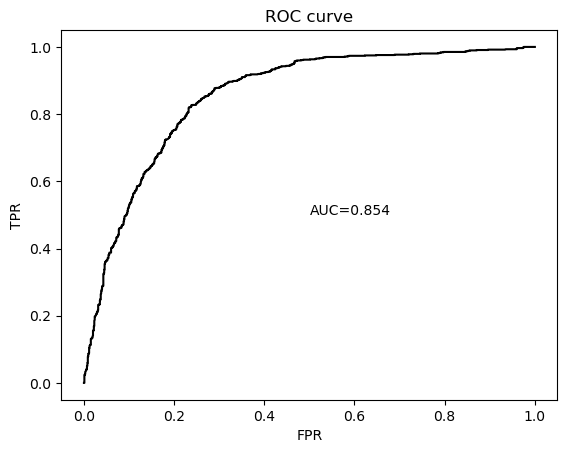

In [29]:
ypp = LogReg.predict_proba(x_test)

fpr, tpr, th = roc_curve(y_test, ypp[:,1])
auc = roc_auc_score(y_test, ypp[:,1])
plt.plot(fpr, tpr, 'k-')
plt.title('ROC curve')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.text(0.5, 0.5, 'AUC='+ "{:.3f}".format(auc))

In [30]:
# Make predictions on the test data
y_pred = LogReg.predict(x_test)

# Calculate precision and recall
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.7536557930258717
Recall: 0.7710011507479861


This model is decent, but not great, after looking at the precision and recall values. Right now I am using all 57 features, when a more simplified model may work better. 

# Random Forest

I want to use Random Forest to help me select which features are the most important.

In [31]:
RF_clf = RandomForestClassifier(n_estimators=200, random_state=1, max_features = 'sqrt', max_depth = 10)
RF_clf.fit(x_train, y_train)
y_pred = RF_clf.predict(x_test)

#print which features are most important
print("Features: Most to Least Important")
print(pd.Series(RF_clf.feature_importances_,index=x_train.columns).sort_values(ascending=False))


precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)

Features: Most to Least Important
BodyLength            0.083228
m80max                0.050750
Species               0.037277
Longitude             0.037038
m70max                0.034163
m100max               0.032719
m90max                0.031861
m50max                0.031790
m60max                0.029936
Genus                 0.028472
m40max                0.028197
Sex                   0.027884
m110max               0.026187
Age                   0.025715
m90min                0.022978
Elevation_100m        0.020325
t20precip_100         0.020103
m70min                0.018668
m100min               0.017597
t30precip_100         0.017087
Latitude              0.017074
t10precip_100         0.015214
m60min                0.015157
t40precip_100         0.014272
t110precip_100        0.014081
t120precip_100        0.013860
t60precip_100         0.013850
m1max                 0.013639
t70precip_100         0.013240
m120max               0.012950
m40min                0.012739
m80mi

I have a slightly improved precision and recall compared to my logistic regression model, but it still can be improved more. 

# Model Reduction

There are many adjustments that can be done to my model from here. One thing I've been wanting to do is to reduce the number of features, but I didn't know which were most important. Some of the most highly correlated features are the max temperature, min temperature, and total precipitation. I wanted to keep the highest ranked feature from each category, and remove the rest, as they are all highly correlated with each other. Based on the above result, I will keep m80max, t20precip_100, and m90min.

In [32]:
data_scale = data_scale.drop(columns=['m1max', 'm7max', 'm10max', 'm20max',
    'm30max', 'm40max', 'm50max', 'm60max', 'm70max', 'm90max', 'm100max', 'm110max', 'm120max',
    'm1min', 'm7min', 'm10min', 'm20min', 'm30min', 'm40min', 'm50min', 'm60min', 'm70min', 'm80min',
    'm100min', 'm110min', 'm120min', 't1precip_100', 't7precip_100', 't10precip_100',
    't30precip_100', 't40precip_100', 't50precip_100', 't60precip_100', 't70precip_100', 't80precip_100',
    't90precip_100', 't100precip_100', 't110precip_100','t120precip_100'])

In [33]:
#separate my features from my result
x = data_scale.drop(columns = "Bd.Result")
y = data_scale['Bd.Result']

#create training and test data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 1)


In [34]:
RF_clf = RandomForestClassifier(n_estimators=200, random_state=1, max_features = 'sqrt', max_depth = 10)
RF_clf.fit(x_train, y_train)
y_pred = RF_clf.predict(x_test)

#print which features are most important
print("Features: Most to Least Important")
print(pd.Series(RF_clf.feature_importances_,index=x_train.columns).sort_values(ascending=False))

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)

Features: Most to Least Important
m80max                0.149327
m90min                0.124925
BodyLength            0.094157
Longitude             0.085826
Species               0.082232
t20precip_100         0.072582
Elevation_100m        0.063477
Month                 0.057289
Latitude              0.056154
Age                   0.055560
Sex                   0.050084
Genus                 0.033086
State                 0.023413
Year_short            0.020431
KGzone                0.011859
reg                   0.011093
order                 0.004535
CaptureEnvironment    0.003971
dtype: float64
Precision: 0.7813141683778234
Recall: 0.8757192174913694


# More Model Tweaking

Now that we have a much more resonable number of features, I wanted to see how correlated these features are.

<Axes: >

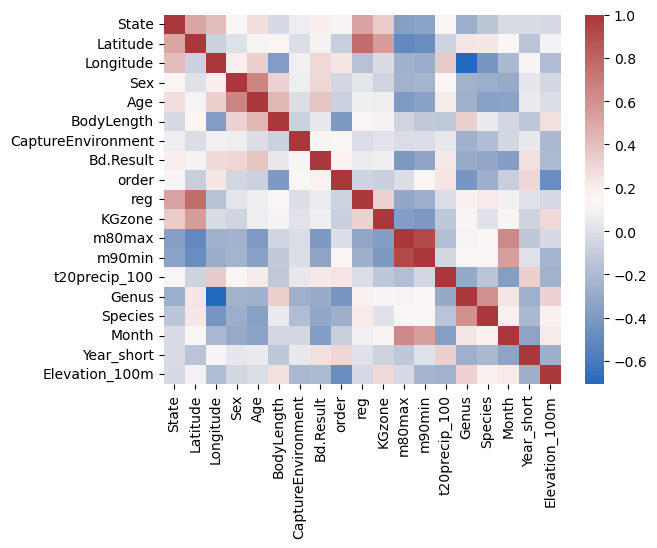

In [35]:
sns.heatmap(data_scale.corr(), cmap = "vlag")

I'm seeing a few highly correlated features. The first one is m80max  and m90min seem highly correlated, which makes sense because if the max temperature is high then so is the min temperature, so I will remove m90min. But, I also know that Chytrid Fungus spread can be impacted by high and low temperatures, so I would like to keep both features in the model.

State is correlated with reg and latitude. Out of those 3 variables, I think state is the least important, so I'd like to remove it. 

In [36]:
data_scale = data_scale.drop(columns=['m90min', 'State'])

In [37]:
#separate my features from my result
x = data_scale.drop(columns = "Bd.Result")
y = data_scale['Bd.Result']

#create training and test data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 1)

RF_clf = RandomForestClassifier(n_estimators=200, random_state=1, max_features = 'sqrt', max_depth = 10)
RF_clf.fit(x_train, y_train)
y_pred = RF_clf.predict(x_test)

#print which features are most important
print("Features: Most to Least Important")
print(pd.Series(RF_clf.feature_importances_,index=x_train.columns).sort_values(ascending=False))

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)

Features: Most to Least Important
m80max                0.185695
Longitude             0.106423
BodyLength            0.096403
t20precip_100         0.090135
Species               0.083747
Month                 0.081529
Elevation_100m        0.074467
Latitude              0.071777
Sex                   0.068489
Genus                 0.047231
Age                   0.038267
Year_short            0.021705
KGzone                0.013716
reg                   0.011522
order                 0.004575
CaptureEnvironment    0.004321
dtype: float64
Precision: 0.7775510204081633
Recall: 0.8768699654775605


# Visualize the most important features

Looking at the most important features, and simplifying that into a reduced model, helps answer some important questions in the dataset.

It tells us that, in terms of temperature, the temperature over the last 80 days seems to have the biggest impact on testing positive for chytrid fungus. Also, looking at another weather related factor, the precipitation over the last 20 days seems to have the biggest impact on testing positive for chytrid fungus. 

The other three features in the top 5 are BodyLength, Longitude and species. Those surprised be a bit more, because I don't know what the size of the amphibian has to do with testing positive for Chytrid Fungus. 0I also don't understand how longitude relates. I assumed that Latitude would be more important, because it's colder up north and warmer down south, but maybe not. 

To help better understand this, I wanted to see the distribution of the top 5 variables in my model

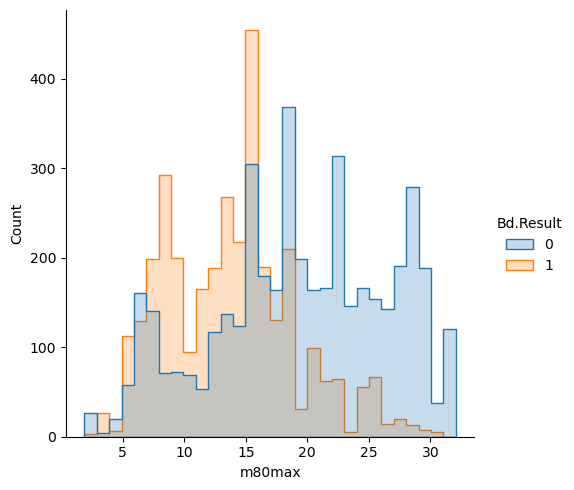

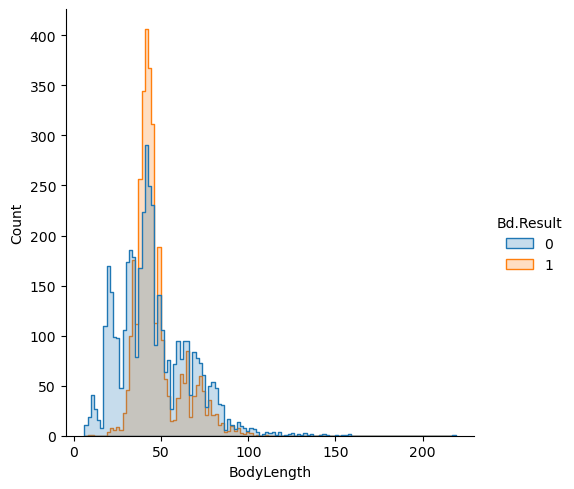

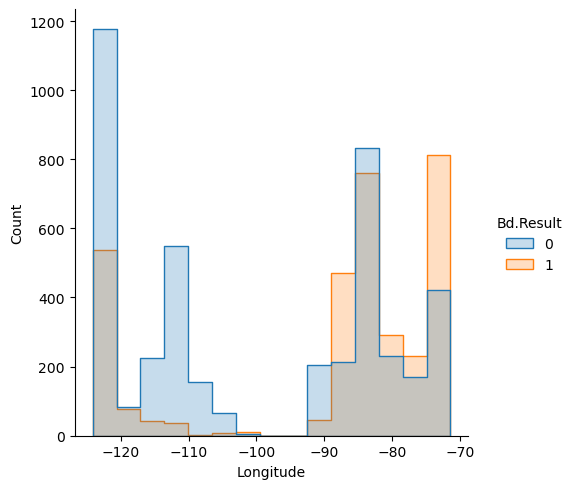

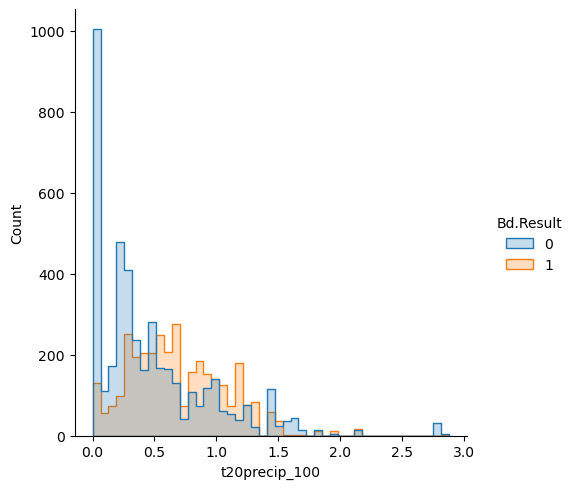

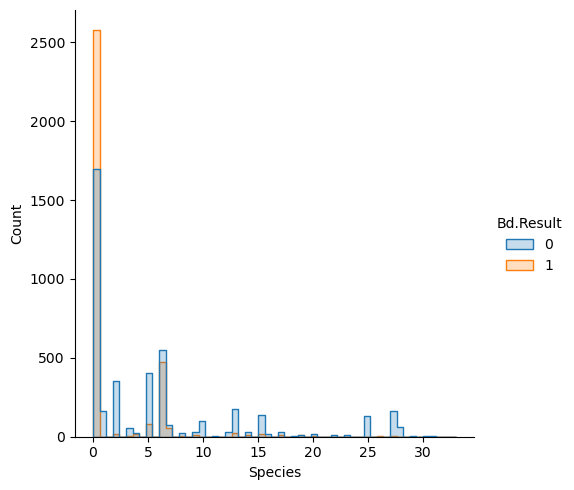

In [39]:
sns.displot(data_scale, x="m80max", hue="Bd.Result", element="step")
sns.displot(data_scale, x="BodyLength", hue="Bd.Result", element="step")
sns.displot(data_scale, x="Longitude", hue="Bd.Result", element="step")
sns.displot(data_scale, x="t20precip_100", hue="Bd.Result", element="step")
sns.displot(data_scale, x="Species", hue="Bd.Result", element="step")



Based on this, I was surpised to find that the amphibians living in the colder temperatures are more likely to test positive than the amphibians living in the warmer temperatures. 

Another interesting find is that it seems that amphibians living in drier climates seem less likely to test positive for chytrid fungus. This is based on the recent precipitation, and also the longitude, because it looks like the west coast has less chytrid fungus but the east coast has more chytrid fungus, most likely because it travels through water.

I am having a harder time interpreting the body length and species graphs. It looks like there's a certain species, the Notophthalmus viridescens, which is testing positive for chitrid fungus much higher than any other species. As juveniles, their size ranges from 34 - 87 mm, which is the peak of the body length graph. While my correlation graph is not showing that those two variables are correlated, they still could explain why the data looks the way it does. 
